# Source Comparison

This notebook compares vocabulary usage across three Hebrew text sources:
songs, news articles, and YouTube content.

The goal is to understand:
- how much vocabulary overlaps between sources
- which sources contribute unique vocabulary
- which words are most characteristic of each source

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

sns.set_theme(style="whitegrid")

In [2]:
query = """
SELECT 
    ws.word_id,
    w.word,
    ws.songs,
    ws.news,
    ws.youtube,
    ws.total
FROM word_sources ws
JOIN words w
ON ws.word_id = w.id;
"""

df_sources = pd.read_sql(query, engine)

df_sources.shape

(13865, 6)

In [3]:
songs_set = set(
    df_sources.loc[df_sources["songs"] > 0, "word_id"]
)

news_set = set(
    df_sources.loc[df_sources["news"] > 0, "word_id"]
)

youtube_set = set(
    df_sources.loc[df_sources["youtube"] > 0, "word_id"]
)

print("Songs:", len(songs_set))
print("News:", len(news_set))
print("YouTube:", len(youtube_set))

Songs: 6285
News: 9577
YouTube: 4049


## Vocabulary Overlap Between Sources

To understand how similar the three language domains are, we compare the sets of words appearing in songs, news, and YouTube content.

Each source is represented as a set of unique `word_id` values. The Venn diagram shows:

- Words shared between multiple sources
- Words unique to a single source
- The size of the common vocabulary across all three domains

This helps identify whether the sources rely on a shared Hebrew vocabulary or contain domain-specific language.

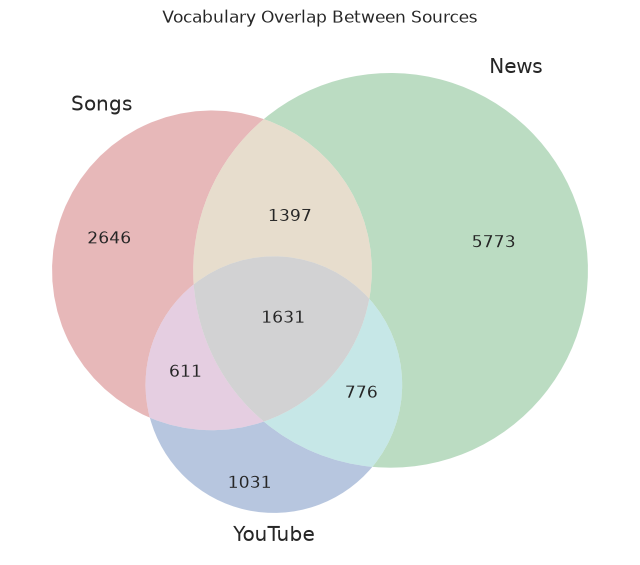

In [4]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

venn3(
    [songs_set, news_set, youtube_set],
    set_labels=("Songs", "News", "YouTube")
)

plt.title("Vocabulary Overlap Between Sources")

plt.show()

### Interpretation

The overlap between sources represents vocabulary shared across different domains of Hebrew usage. A large central intersection suggests a common core vocabulary, while the source-specific regions highlight words that are characteristic of individual domains.

Because each source represents a different type of language usage, differences in overlap may reflect stylistic and contextual variation rather than differences in the language itself.

## Most Frequent Words by Source

After examining vocabulary overlap, we analyze the most frequent words within each source separately.

This reveals which words dominate each domain and highlights differences between songs, news, and YouTube vocabulary.

In [5]:
with open("../data/stopwords.txt", "r", encoding="utf-8") as f:
    stopwords = set(
        line.strip()
        for line in f
        if line.strip()
    )

df_filtered = df_sources[
    ~df_sources["word"].isin(stopwords)
]

In [6]:
top_songs = (
    df_filtered
    .sort_values("songs", ascending=False)
    [["word", "songs"]]
    .head(20)
)

top_songs

,word,songs
10541,עושה,200
795,בא,173
13017,תגידי,143
4741,יפה,116
4339,יודעת,116
125,אוהב,109
148,אוי,107
2123,הזמן,106
94,אהבה,95
2231,היית,93


In [7]:
top_news = (
    df_filtered
    .sort_values("news", ascending=False)
    [["word", "news"]]
    .head(20)
)

top_news

,word,news
1110,בני,223
784,אתמול,217
11847,ראש,202
549,אמר,181
11863,רבים,166
505,אלף,165
12760,שנים,131
3492,חג,116
7438,מיליון,112
8669,משרד,109


In [8]:
top_youtube = (
    df_filtered
    .sort_values("youtube", ascending=False)
    [["word", "youtube"]]
    .head(20)
)

top_youtube

,word,youtube
12542,שיר,1451
8396,מרגש,429
2882,השיר,389
7334,מטורף,258
4741,יפה,257
1190,בר,246
6717,מדהים,211
7075,מושלם,148
473,אלוף,144
10148,סוף,137


### Interpretation

After removing common Hebrew stopwords, each source shows a distinct vocabulary profile.

Songs contain words associated with personal emotions, relationships, and internal experiences.

News vocabulary reflects informational reporting, with frequent references to institutions, public figures, locations, and quantitative information.

YouTube vocabulary is dominated by evaluative and emotional reactions, reflecting audience responses rather than the content itself.

These differences demonstrate that the three sources represent different communication contexts: expression (songs), information delivery (news), and social evaluation (YouTube).

## Top Vocabulary by Source

To compare the linguistic characteristics of each source, the 50 most frequent words were extracted separately from songs, news, and YouTube data.

Before this step, common Hebrew stopwords were removed to reduce the influence of high-frequency grammatical words (such as pronouns, prepositions, and conjunctions) that appear across all domains.

The goal is not to measure overall word frequency, but to identify the most representative content vocabulary within each source.

The resulting datasets contain:
- **Songs:** top 50 most frequent words after stopword removal
- **News:** top 50 most frequent words after stopword removal
- **YouTube:** top 50 most frequent words after stopword removal

These vocabulary lists will later be enriched with linguistic metadata (meaning and part of speech) and analyzed using LLM-assisted semantic categorization.

In [9]:
top_songs = (
    df_filtered
    .sort_values("songs", ascending=False)
    [["word", "songs"]]
    .head(50)
    .rename(columns={"songs": "freq"})
)

top_songs["source"] = "songs"


top_news = (
    df_filtered
    .sort_values("news", ascending=False)
    [["word", "news"]]
    .head(50)
    .rename(columns={"news": "freq"})
)

top_news["source"] = "news"


top_youtube = (
    df_filtered
    .sort_values("youtube", ascending=False)
    [["word", "youtube"]]
    .head(50)
    .rename(columns={"youtube": "freq"})
)

top_youtube["source"] = "youtube"

top_words_combined = pd.concat(
    [
        top_songs,
        top_news,
        top_youtube
    ],
    ignore_index=True
)

top_words_combined.shape

top_words_combined

,word,freq,source
0,עושה,200,songs
1,בא,173,songs
2,תגידי,143,songs
3,יפה,116,songs
4,יודעת,116,songs
...,...,...,...
145,רבה,61,youtube
146,בננה,59,youtube
147,פסח,59,youtube
148,צמרמורות,55,youtube


In [10]:
query = """
SELECT id AS word_id, word
FROM words;
"""

df_word_ids = pd.read_sql(query, engine)

top_words_combined = top_words_combined.merge(
    df_word_ids,
    on="word",
    how="left"
)

top_words_combined.head()

,word,freq,source,word_id
0,עושה,200,songs,9be7b963-5f34-4f3b-b902-752974494379
1,בא,173,songs,ec76909d-7031-410b-90dd-9d3f20190a98
2,תגידי,143,songs,fd41c2e1-8737-4848-939e-a39d6c807cb2
3,יפה,116,songs,9c627192-0733-4367-a6aa-33df6f12b818
4,יודעת,116,songs,abacc3bd-25e7-4ec0-a3f8-cdef8ab2e2c0


In [11]:
word_ids_str = "', '".join(
    top_words_combined["word_id"].dropna().astype(str)
)

query = f"""
SELECT 
    wl.word_id,
    l.meaning,
    l.part_of_speech
FROM word_lemmas wl
JOIN lemmas l
ON l.id = wl.lemma_id
WHERE wl.word_id IN ('{word_ids_str}');
"""

df_meanings = pd.read_sql(query, engine)


In [12]:
df_meanings_agg = (
    df_meanings
    .groupby("word_id")
    .agg({
        "meaning": lambda x: "; ".join(x.dropna().unique()),
        "part_of_speech": lambda x: "; ".join(x.dropna().unique())
    })
    .reset_index()
)

In [13]:
top_words_combined = top_words_combined.merge(
    df_meanings_agg,
    on="word_id",
    how="left"
)

top_words_combined = top_words_combined.reset_index(drop=True)
top_words_combined["row_id"] = top_words_combined.index

In [14]:
top_words_combined.tail()

,word,freq,source,word_id,meaning,part_of_speech,row_id
145,רבה,61,youtube,77d195af-f6f0-4fa4-92b8-ea671b1d019f,"vast, great; numerous; multi- (in compound wor...",Adjective - kal pattern; Verb - pa'al,145
146,בננה,59,youtube,b433b97c-c9f2-4097-80ec-4d21a247fa01,banana,Noun - feminine,146
147,פסח,59,youtube,6e465831-b05b-4cc6-8fa5-f867a408d544,"to skip, to pass over (על); Passover (jewish h...","Verb - pa'al; Noun - ketel pattern , masculine",147
148,צמרמורות,55,youtube,a1ca9783-cea8-4611-813d-1bd7f1e172ac,"shivering, chill, goosebumps, shudder","Noun - ktaltolet pattern , feminine",148
149,מלא,53,youtube,d13d6b89-53e5-4c7e-bfea-5776846c6f05,"to be full; to become full; to complete, to be...",Verb - pa'al; Adjective - katel pattern; Verb ...,149


In [15]:
import os
import json
import time
from pydantic import BaseModel, Field
from google import genai
from google.genai import types





LABEL_FILE = "../data/word_semantic_labels.csv"

if os.path.exists(LABEL_FILE):
    print(f"{LABEL_FILE} already exists. Loading existing labels.")
    df_labels = pd.read_csv(LABEL_FILE)
    print(f"Loaded {len(df_labels)} labels.")

else:
    load_dotenv()
    api_key = os.getenv("GEMINI_API_KEY")
    if not api_key:
        raise ValueError("GEMINI_API_KEY not found in environment variables. Check your .env file setup.")

    client = genai.Client(
        api_key=api_key,
        http_options=types.HttpOptions(timeout=90000)
    )

    class WordLabel(BaseModel):
        row_id: int
        word: str
        label: str = Field(
            description="""
            Must be exactly one of:
            emotional_social,
            public_formal,
            informal_everyday,
            neutral_general
            """
        )

    class BatchLabelResponse(BaseModel):
        results: list[WordLabel]

    def label_batch(batch_rows, retries=3, pause_duration=20):
        items = [
            {"row_id": r["row_id"], "word": r["word"], "meaning": r["meaning"], "part_of_speech": r["part_of_speech"]}
            for r in batch_rows
        ]
        prompt = f"""
        You are a Hebrew linguist.

        Classify each word into the category that best describes its typical usage.

        Categories:

        1. emotional_social:
           emotions, relationships, personal experiences, artistic expression.

        2. public_formal:
           politics, institutions, official language, news, academic topics.

        3. informal_everyday:
           casual speech, slang, internet expressions, personal reactions.

        4. neutral_general:
           common words without a strong domain or register association.

        Use the word meaning and part of speech.
        Do not infer from frequency alone.
            Words: {json.dumps(items, ensure_ascii=False)}
        """

        for attempt in range(retries):
            try:
                response = client.models.generate_content(
                    model="gemini-3.1-flash-lite",
                    contents=prompt,
                    config=types.GenerateContentConfig(
                        response_mime_type="application/json",
                        response_schema=BatchLabelResponse,
                        temperature=0.1
                    )
                )
                data = json.loads(response.text)
                return data.get("results", [])

            except Exception as e:
                if "429" in str(e):
                    print(f"\n[Quota Exceeded] Pausing {pause_duration}s before retry {attempt + 1}/{retries}...")
                    time.sleep(pause_duration)
                else:
                    print(f"\n[API Error] {e}")
                    raise e

        print(f"\n[Failed] Batch dropped after {retries} retry attempts.")
        return []

    rows = top_words_combined.to_dict('records')
    batch_size = 35
    batches = [rows[i:i+batch_size] for i in range(0, len(rows), batch_size)]
    print(f"{len(batches)} batches of up to {batch_size} words each")

    all_labels = []
    for i, batch in enumerate(batches):
        print(f"Labeling batch {i+1}/{len(batches)}...")
        labels = label_batch(batch)
        all_labels.extend(labels)
        time.sleep(6)

    print(f"\nTotal labeled: {len(all_labels)}")

    if not all_labels:
        print("\nNo labels returned — check errors above.")
    df_labels = pd.DataFrame(all_labels)
    df_labels.to_csv(LABEL_FILE, index=False)


# --- the ONLY merge in this cell, runs no matter which branch executed above ---
top_words_combined = top_words_combined.merge(
    df_labels[["row_id", "label"]], on="row_id", how="left"
)
print("\nLabel distribution:")
print(top_words_combined['label'].value_counts())

../data/word_semantic_labels.csv already exists. Loading existing labels.
Loaded 150 labels.

Label distribution:
label
neutral_general      80
emotional_social     32
informal_everyday    20
public_formal        18
Name: count, dtype: int64


In [16]:
label_distribution = (
    top_words_combined
    .groupby(["source", "label"])
    .size()
    .reset_index(name="count")
)

label_distribution


,source,label,count
0,news,emotional_social,1
1,news,neutral_general,36
2,news,public_formal,13
3,songs,emotional_social,9
4,songs,informal_everyday,15
5,songs,neutral_general,25
6,songs,public_formal,1
7,youtube,emotional_social,22
8,youtube,informal_everyday,5
9,youtube,neutral_general,19


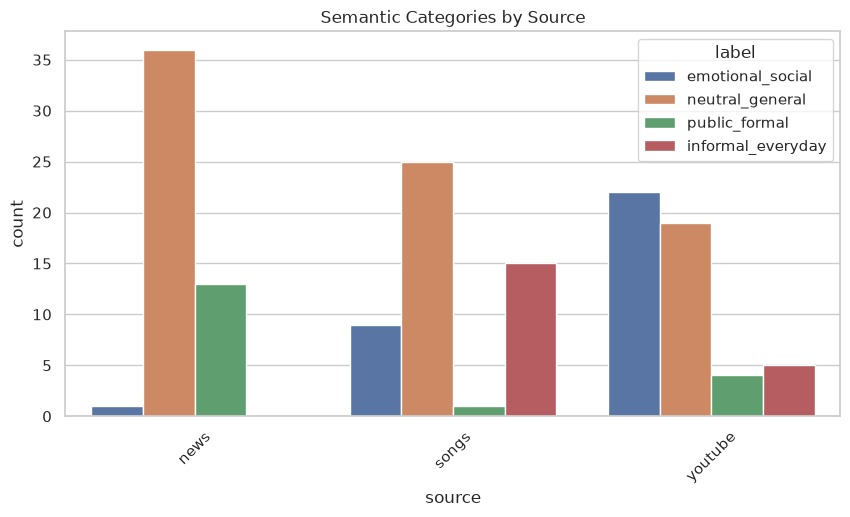

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(
    data=label_distribution,
    x="source",
    y="count",
    hue="label"
)

plt.title("Semantic Categories by Source")
plt.xticks(rotation=45)
plt.show()

## Interpretation of Source Vocabulary Differences

The semantic categorization reveals differences in vocabulary characteristics across songs, news, and YouTube.

An LLM-assisted annotation step was used to classify vocabulary items into four broad categories: emotional-social, public-formal, informal-everyday, and neutral-general. The model received only the word, its meaning, and grammatical category, while source information was excluded to reduce bias.

The results show that news contains a higher proportion of public-formal vocabulary, reflecting terminology related to institutions, public events, and official discourse. However, neutral vocabulary remains dominant, showing that news also relies heavily on general language.

Songs show a stronger presence of emotional-social and informal-everyday vocabulary, consistent with personal experiences, relationships, and direct communication.

YouTube vocabulary contains many emotional-social expressions and fewer informal terms than expected. This may be influenced by the dataset composition, as popular Hebrew YouTube content likely includes a significant amount of entertainment and music-related content. Therefore, these results represent the language of the collected videos rather than all informal online Hebrew communication.

Overall, the findings suggest that different sources capture different aspects of Hebrew usage. Since classification was performed on isolated words without sentence-level context, results should be interpreted as exploratory.